In [1]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [2]:
im_or = cv2.imread("PirabasB_2 - Copy.tif")

In [3]:
im_or.shape


(768, 1024, 3)

In [57]:
im_or.min(), im_or.max()

(0, 255)

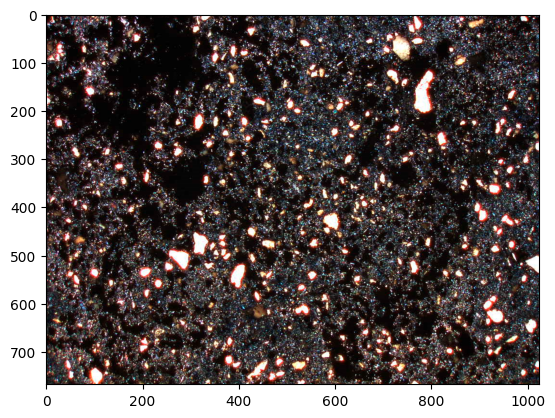

In [4]:
plt.imshow(im_or)

In [5]:
import cv2
# Convert the image to grayscale
grayscale_image = cv2.cvtColor(im_or, cv2.COLOR_BGR2GRAY)

In [6]:
grayscale_image.shape

(768, 1024)

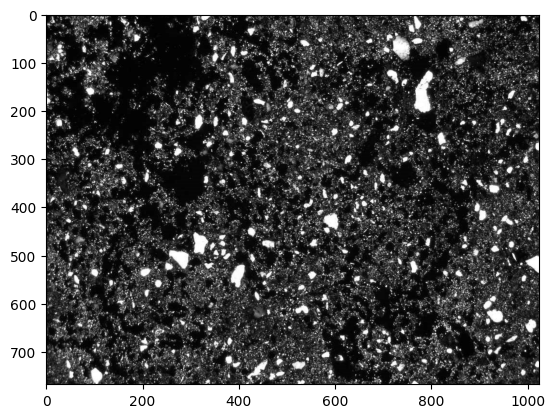

In [7]:
plt.imshow(grayscale_image, cmap="gray")

In [8]:
# Let's see the data as each vector (features) to a regression model
x_weidth, y_height = grayscale_image.shape
grayscale_image.shape, x_weidth, y_height

((768, 1024), 768, 1024)

In [9]:
range(0,x_weidth), range(0, y_height)

(range(0, 768), range(0, 1024))

In [10]:
# Generate the model
# Save each characteristic of the image as features (the pixel value, axis x and y);
pixels_values = [];
axis_x_vector = [];
axis_y_vector = [];

for ii in range(0,x_weidth):
  for jj in range(0,y_height):
    pixel_value_temp = grayscale_image[ii,jj]
    ii_temp = ii
    jj_temp = jj
    pixels_values.append(pixel_value_temp)
    axis_x_vector.append(ii_temp)
    axis_y_vector.append(jj_temp)

In [11]:
len(pixels_values), len(axis_x_vector), len(axis_y_vector)

(786432, 786432, 786432)

In [12]:
import random
Random_values= random.randint(0,len(pixels_values))
Random_values

237986

In [13]:
print("The index", Random_values)
#Checkinf the values and the spatial variation
pixels_values[Random_values] == grayscale_image[axis_x_vector[Random_values],axis_y_vector[Random_values]]

The index 237986


True

In [14]:
#Convert to a numpy array
pixels_values =np.array(pixels_values)
axis_x_vector = np.array(axis_x_vector)
axis_y_vector = np.array(axis_y_vector)

In [15]:
#check the range of the values
pixels_values.min(), pixels_values.max()

(0, 255)

In [16]:
#Let's normalize the data
pixels_values_normalize = (pixels_values - pixels_values.min())/(pixels_values.max() - pixels_values.min())

In [17]:
pixels_values_normalize.min(), pixels_values_normalize.max()

(0.0, 1.0)

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Prepare the input features by stacking the axis vectors and reshaping for CNN
X = np.column_stack((axis_x_vector, axis_y_vector)).reshape(-1, 2, 1)
y = pixels_values_normalize
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the CNN model
model = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(2, 1)),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer=Adam(), loss='mean_squared_error')

In [56]:
# In that case the X will be pars of axis_x_vector and axis_y_vector
# for instance: [axis_x_vector[0], axis_y_vector[0],..., axis_x_vector[n], axis_y_vector[n] ]
X.shape

(786432, 2, 1)

In [19]:
# Train the model
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
17204/17204 [==============================] - 42s 2ms/step - loss: 4.5530
Epoch 2/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0953
Epoch 3/10
17204/17204 [==============================] - 42s 2ms/step - loss: 0.0605
Epoch 4/10
17204/17204 [==============================] - 42s 2ms/step - loss: 0.0527
Epoch 5/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 6/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 7/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 8/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 9/10
17204/17204 [==============================] - 41s 2ms/step - loss: 0.0527
Epoch 10/10
7373/7373 [==============================] - 6s 818us/step
Mean Squared Error: 0.0524507139025643
Predicted values: [0.20665552 0.20665552 0.20665552 ... 0.20665552 0.20665552 0.20665552]
Actual values: [0.05098039

In [55]:
X_test.shape

(235930, 2, 1)

In [20]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Display predictions
print(f'Predicted values: {y_pred.flatten()}')
print(f'Actual values: {y_test}')

7373/7373 [==============================] - 6s 778us/step
Mean Squared Error: 0.0524507139025643
Predicted values: [0.20665552 0.20665552 0.20665552 ... 0.20665552 0.20665552 0.20665552]
Actual values: [0.05098039 0.84313725 0.16470588 ... 0.20392157 0.00784314 0.16470588]


In [23]:
len(y_pred), len(X_test)

(235930, 235930)

## Predict the original image with the model

In [26]:
im_or.shape, grayscale_image.shape

((768, 1024, 3), (768, 1024))

In [27]:
grayscale_image.min(), grayscale_image.max()

(0, 255)

In [28]:
# Normalize the data
grayscale_image_normalized = (grayscale_image - grayscale_image.min())/(grayscale_image.max() - grayscale_image.min())

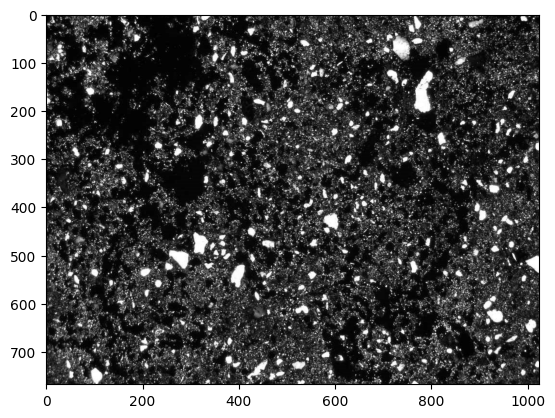

In [29]:
plt.imshow(grayscale_image_normalized, cmap = "gray")

In [30]:
## Let's use the model to reconstruct the image
# Prepare the input features by stacking the axis vectors and reshaping for CNN
X_feature_to_predicit = np.column_stack((axis_x_vector, axis_y_vector)).reshape(-1, 2, 1)

In [31]:
# Make predictions
y_pred_values = model.predict(X_feature_to_predicit)


24576/24576 [==============================] - 23s 934us/step


In [32]:
import numpy as np

# Initialize an empty image array with the same dimensions as the original image
reconstructed_image = np.zeros((x_weidth, y_height), dtype=np.uint8)

# Iterate through the vectors and place each pixel value back into its position
for k in range(len(y_pred_values)):
    ii = axis_x_vector[k]
    jj = axis_y_vector[k]
    reconstructed_image[ii, jj] = pixels_values[k]

# The reconstructed_image now holds the original image


In [33]:
reconstructed_image.shape

(768, 1024)

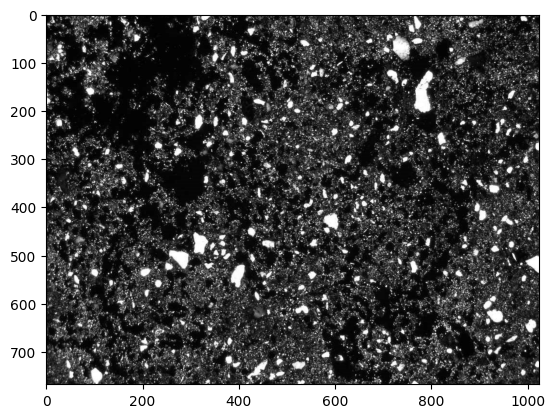

In [34]:
plt.imshow(reconstructed_image, cmap="gray")

In [38]:
grayscale_image.min(), grayscale_image.max(), reconstructed_image.min(), reconstructed_image.max()

(0, 255, 0, 255)

In [39]:
grayscale_image == reconstructed_image

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [46]:
c_false = 0
c_true = 0
for ii in range(0,x_weidth):
  for jj in range(0,y_height):
    temp_bool = grayscale_image[ii,jj] == reconstructed_image[ii,jj]
    if temp_bool == False:
        c_false = c_false + 1
    elif temp_bool == True:
        c_true = c_true + 1
        


In [49]:
c_true == len(axis_x_vector), c_false, c_true, len(axis_x_vector)

(True, 0, 786432, 786432)

In [51]:
# Function to reconstruct the original image and mask
import numpy as np

def jaccard_similarity(image, image_2):
    # Flatten the images to 1D arrays
    image_flat = image.flatten()
    image_2_flat = image_2.flatten()

    # Calculate intersection (number of matching pixels)
    intersection = np.sum(np.logical_and(image_flat, image_2_flat))

    # Calculate union (number of pixels marked as foreground in either image or mask)
    union = np.sum(np.logical_or(image_flat, image_2_flat))

    # Calculate Jaccard similarity coefficient
    jaccard = intersection / union

    return jaccard

In [54]:
jaccard_metric_or_rec = jaccard_similarity(grayscale_image, reconstructed_image)
print("The jaccard similarity between the original image and the reconstruct image is:", jaccard_metric_or_rec)

The jaccard similarity between the original image and the reconstruct image is: 1.0


## Apply the Difusion process

In [58]:
import numpy as np

def forward_process(image, timesteps, beta):
    noisy_images = []
    for t in range(timesteps):
        noise = np.random.normal(0, beta, image.shape)
        image = image + noise
        noisy_images.append(image)
    return noisy_images

def reverse_process(noisy_images, model):
    for t in reversed(range(len(noisy_images))):
        noisy_image = noisy_images[t]
        noise_estimate = model.predict(noisy_image)  # Modelo treinado para prever o ruído
        noisy_image = noisy_image - noise_estimate
    return noisy_image

In [108]:
# Process de difusão progressiva
# Exemplo de uso
timesteps = 100
beta = 8

noisy_images = forward_process(grayscale_image, timesteps, beta)


In [109]:
noisy_images = np.array(noisy_images)
noisy_images.shape

(100, 768, 1024)

In [153]:
## hello

14


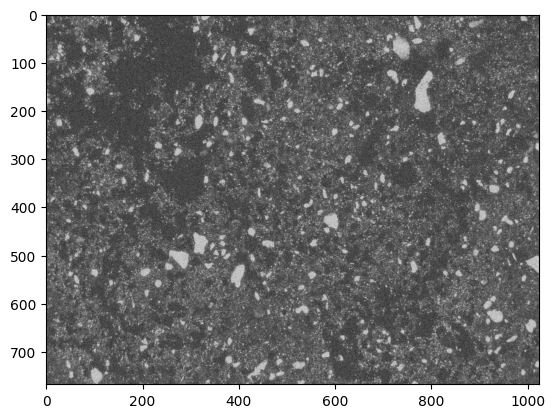

In [152]:
index_noisy_images = random.randint(0,len(noisy_images)-1)
print(index_noisy_images)
plt.imshow(noisy_images[index_noisy_images,:, :], cmap="gray")

In [137]:
## Pressão, velocidade and modulo elástico.
